In [ ]:
# Cell 1: Install/upgrade libraries (if needed)
!pip install -q tensorflow matplotlib numpy scikit-learn seaborn

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 2: Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Cell 3: Load CIFAR-10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set: {train_images.shape}, Labels: {train_labels.shape}")
print(f"Test set:     {test_images.shape}, Labels: {test_labels.shape}")
print(f"Pixel value range: [{train_images.min()}, {train_images.max()}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1934s 11us/step
Training set: (50000, 32, 32, 3), Labels: (50000, 1)
Test set:     (10000, 32, 32, 3), Labels: (10000, 1)
Pixel value range: [0, 255]


In [ ]:
# Cell 4: Normalize pixel values to [0, 1]
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm  = test_images.astype('float32') / 255.0

# One-hot encode labels
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat  = to_categorical(test_labels, 10)

print(f"Normalized range: [{train_images_norm.min():.1f}, {train_images_norm.max():.1f}]")

Normalized range: [0.0, 1.0]


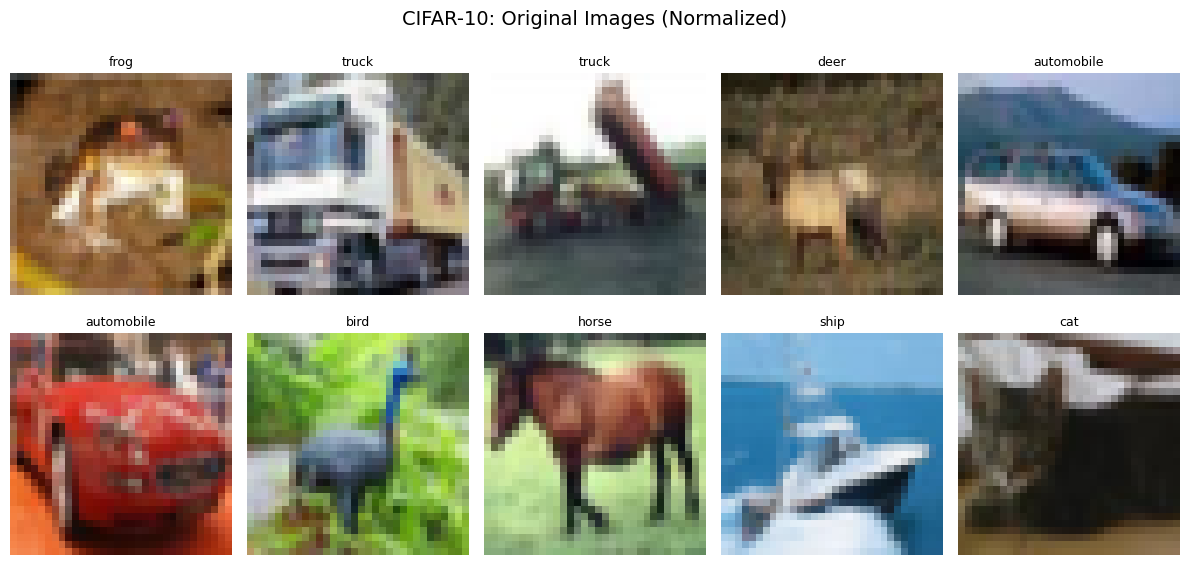

In [ ]:
# Cell 5: Visualize sample images before augmentation
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images_norm[i])
    plt.title(class_names[train_labels[i][0]], fontsize=9)
    plt.axis('off')
plt.suptitle("CIFAR-10: Original Images (Normalized)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Full augmentation pipeline using Keras preprocessing layers
data_augmentation = tf.keras.Sequential([
    # 1. Random Cropping (simulated via random zoom + random translation)
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),

    # 2. Random Rotation
    layers.RandomRotation(factor=0.15),  # ±15° (15% of 2π)

    # 3. Random Flipping
    layers.RandomFlip(mode="horizontal"),

    # 4. Brightness & Contrast Adjustment
    layers.RandomBrightness(factor=0.15, value_range=(0.0, 1.0)),
    layers.RandomContrast(factor=0.15),

    # 5. Color & Saturation Augmentation
    layers.RandomSaturation(factor=(0.7, 1.3)),
    layers.RandomHue(factor=0.05),
], name="data_augmentation")

print("Augmentation pipeline created with:")
for layer in data_augmentation.layers:
    print(f"  • {layer.__class__.__name__}")

Augmentation pipeline created with:
  • RandomZoom
  • RandomRotation
  • RandomFlip
  • RandomBrightness
  • RandomContrast
  • RandomSaturation
  • RandomHue


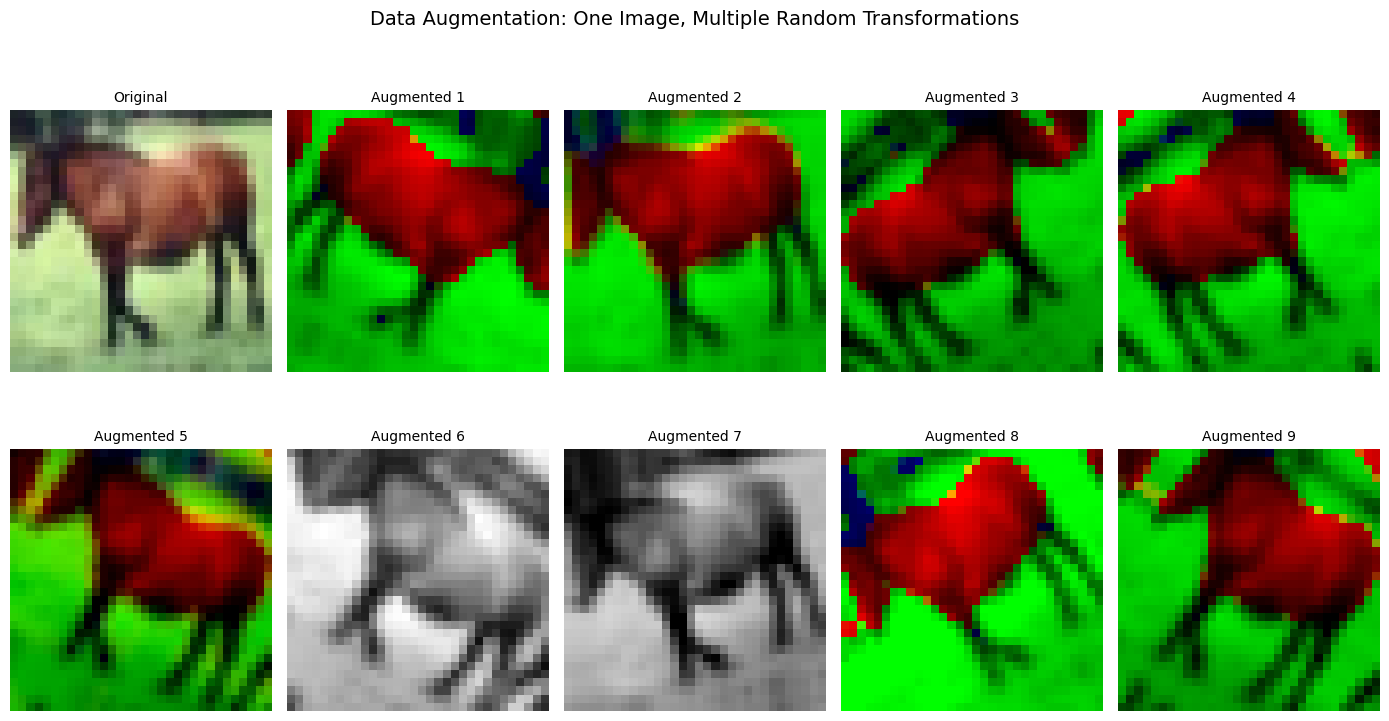

In [ ]:
# Cell 7: Visualize augmentation effects on a single image
sample_image = train_images_norm[7]  # pick an image
sample_image_expanded = tf.expand_dims(sample_image, 0)

plt.figure(figsize=(14, 8))
# Original
plt.subplot(2, 5, 1)
plt.imshow(sample_image)
plt.title("Original", fontsize=10)
plt.axis('off')

# Augmented versions
for i in range(9):
    augmented = data_augmentation(sample_image_expanded, training=True)
    plt.subplot(2, 5, i + 2)
    plt.imshow(augmented[0].numpy())
    plt.title(f"Augmented {i+1}", fontsize=10)
    plt.axis('off')

plt.suptitle("Data Augmentation: One Image, Multiple Random Transformations", fontsize=14)
plt.tight_layout()
plt.show()

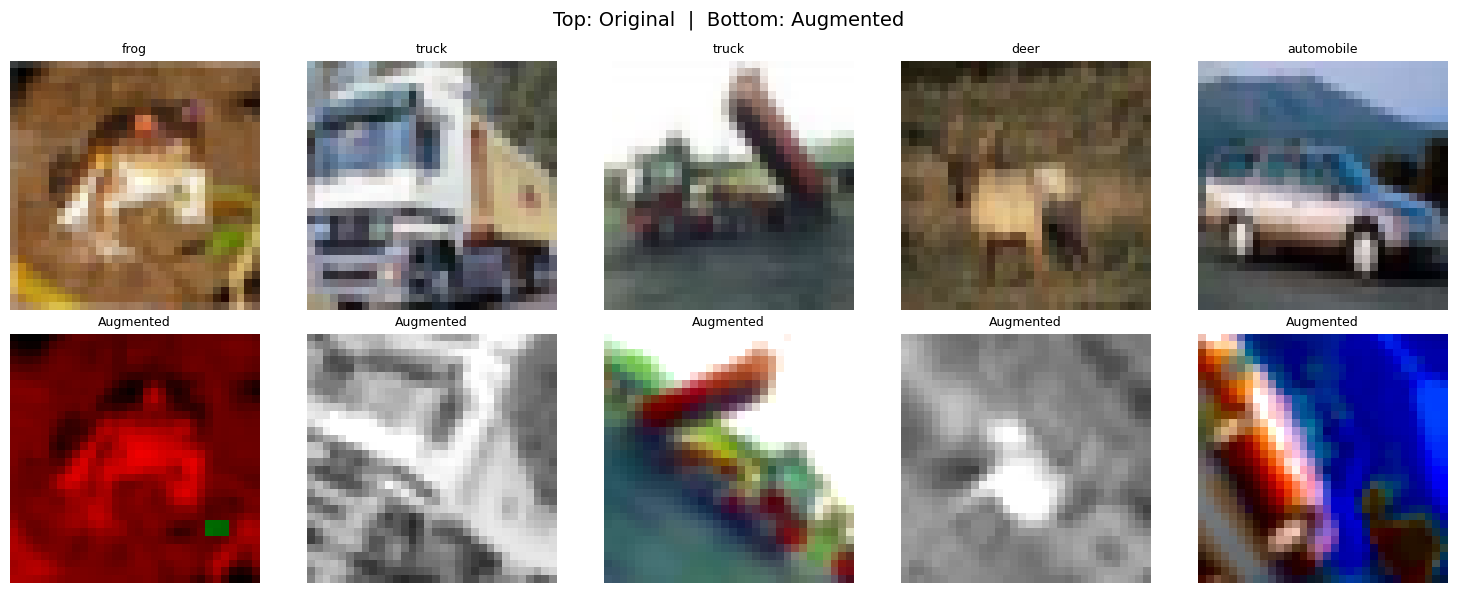

In [ ]:
# Cell 8: Visualize individual augmentation effects for a grid of images
def show_augmentation_grid(images, labels, augmenter, n=5):
    """Show original vs augmented for n images."""
    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i][0]], fontsize=9)
        plt.axis('off')
        # Augmented
        aug = augmenter(tf.expand_dims(images[i], 0), training=True)
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(aug[0].numpy())
        plt.title("Augmented", fontsize=9)
        plt.axis('off')
    plt.suptitle("Top: Original  |  Bottom: Augmented", fontsize=14)
    plt.tight_layout()
    plt.show()

show_augmentation_grid(train_images_norm, train_labels, data_augmentation, n=5)

In [ ]:
# Cell 9: Define a reusable CNN builder
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    """Build a compact CNN for CIFAR-10."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name="baseline_cnn")
    return model

baseline_model = build_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Cell 10: Compile and train baseline model
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    train_images_norm, train_labels_cat,
    batch_size=128,
    epochs=30,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.4494 - loss: 1.5736 - val_accuracy: 0.3148 - val_loss: 2.7416
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5868 - loss: 1.1595 - val_accuracy: 0.5872 - val_loss: 1.2216
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6442 - loss: 1.0024 - val_accuracy: 0.6016 - val_loss: 1.1775
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6826 - loss: 0.8988 - val_accuracy: 0.6656 - val_loss: 0.9391
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7114 - loss: 0.8170 - val_accuracy: 0.6922 - val_loss: 0.9138
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7322 - loss: 0.7563 - val_accuracy: 0.7216 - val_loss: 0.7876
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7526 - loss: 0.7047 - val_accuracy: 0.7184 - val_loss: 0.8121
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7693 - loss: 0.6488 - val_accuracy:

In [ ]:
# Cell 11: Build model with augmentation integrated
def build_augmented_cnn(input_shape=(32, 32, 3), num_classes=10, augmenter=None):
    """Build CNN with augmentation layers as part of the model."""
    model = models.Sequential(name="augmented_cnn")

    # Input + Augmentation (only active during training)
    model.add(layers.Input(shape=input_shape))
    if augmenter is not None:
        model.add(augmenter)

    # Convolutional base
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

augmented_model = build_augmented_cnn(augmenter=data_augmentation)
augmented_model.summary()

Model: "augmented_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Cell 12: Compile and train augmented model
augmented_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

augmented_history = augmented_model.fit(
    train_images_norm, train_labels_cat,
    batch_size=128,
    epochs=30,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.2907 - loss: 2.0149 - val_accuracy: 0.2244 - val_loss: 3.1527
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3678 - loss: 1.7567 - val_accuracy: 0.4602 - val_loss: 1.5413
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4107 - loss: 1.6436 - val_accuracy: 0.4798 - val_loss: 1.4275
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4440 - loss: 1.5573 - val_accuracy: 0.5062 - val_loss: 1.4263
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4668 - loss: 1.5059 - val_accuracy: 0.5824 - val_loss: 1.2011
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4894 - loss: 1.4452 - val_accuracy: 0.5748 - val_loss: 1.2190
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5030 - loss: 1.4085 - val_accuracy: 0.5786 - val_loss: 1.2309
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5177 - loss: 1.3726 - val_ac

In [ ]:
# Cell 13: Generate an augmented dataset (e.g., 2x original size)
def create_augmented_dataset(images, labels, augmenter, multiplier=2):
    """
    Create an expanded dataset by applying augmentation.
    multiplier=2 → 2x original number of images.
    """
    augmented_images = [images]
    augmented_labels = [labels]

    for _ in range(multiplier - 1):
        aug_batch = augmenter(images, training=True)
        augmented_images.append(aug_batch.numpy())
        augmented_labels.append(labels)

    return np.concatenate(augmented_images, axis=0), np.concatenate(augmented_labels, axis=0)

# Generate 2x augmented training set
augmented_train_images, augmented_train_labels = create_augmented_dataset(
    train_images_norm, train_labels_cat, data_augmentation, multiplier=2
)

print(f"Original training set:  {train_images_norm.shape}")
print(f"Augmented training set: {augmented_train_images.shape}")
print(f"Size increase: {augmented_train_images.shape[0] / train_images_norm.shape[0]:.1f}x")

Original training set:  (50000, 32, 32, 3)
Augmented training set: (100000, 32, 32, 3)
Size increase: 2.0x


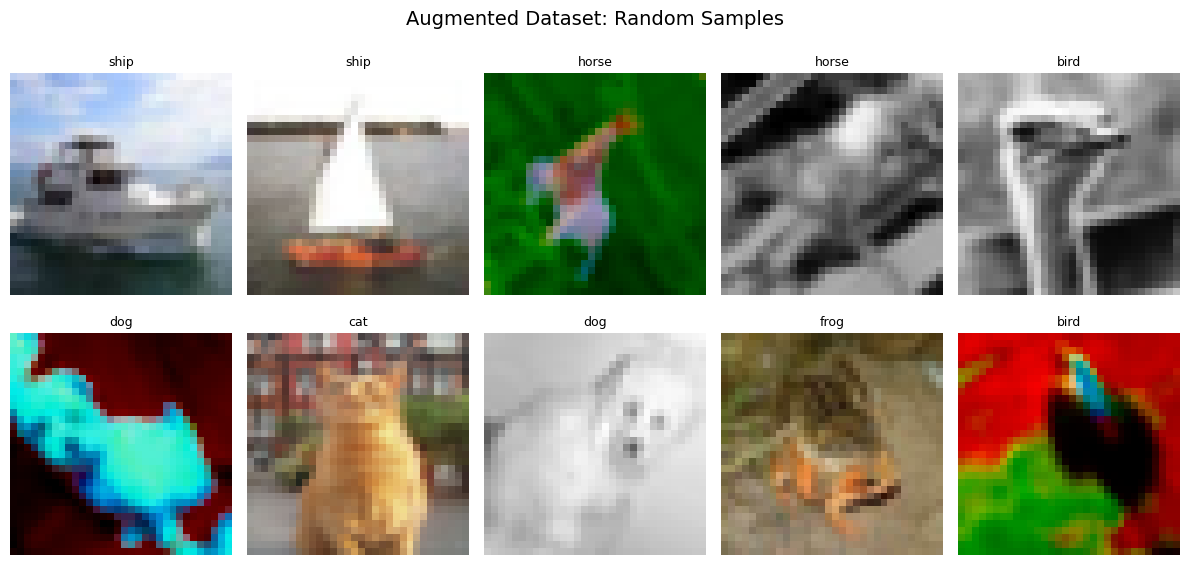

In [ ]:
# Cell 14: Visualize samples from the augmented dataset
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, augmented_train_images.shape[0])
    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_train_images[idx])
    plt.title(class_names[np.argmax(augmented_train_labels[idx])], fontsize=9)
    plt.axis('off')
plt.suptitle("Augmented Dataset: Random Samples", fontsize=14)
plt.tight_layout()
plt.show()

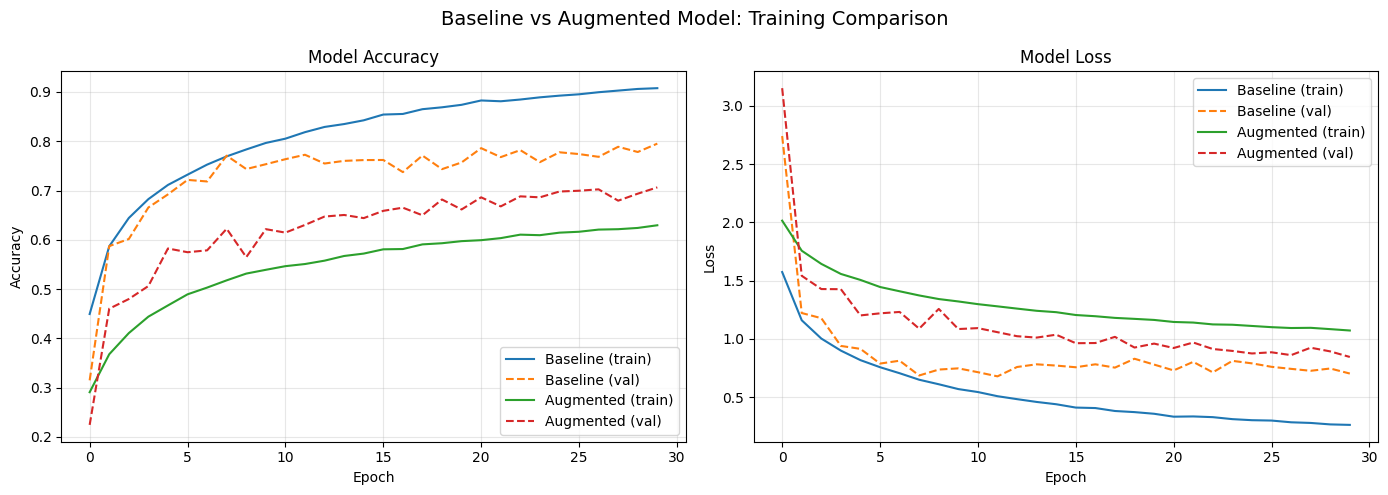

In [ ]:
# Cell 15: Plot training curves comparison
def plot_training_history(histories, names, metric='accuracy'):
    """Plot training and validation curves for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, name in zip(histories, names):
        # Training metric
        axes[0].plot(hist.history[metric], label=f'{name} (train)')
        axes[0].plot(hist.history[f'val_{metric}'], '--', label=f'{name} (val)')

        # Loss
        axes[1].plot(hist.history['loss'], label=f'{name} (train)')
        axes[1].plot(hist.history['val_loss'], '--', label=f'{name} (val)')

    axes[0].set_title(f'Model {metric.capitalize()}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel(metric.capitalize())
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Baseline vs Augmented Model: Training Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_history(
    [baseline_history, augmented_history],
    ['Baseline', 'Augmented'],
    metric='accuracy'
)

In [ ]:
# Cell 16: Evaluate both models on test set
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(
    test_images_norm, test_labels_cat, verbose=0
)
augmented_test_loss, augmented_test_acc = augmented_model.evaluate(
    test_images_norm, test_labels_cat, verbose=0
)

# Also evaluate on the augmented training set to check generalization
baseline_train_loss, baseline_train_acc = baseline_model.evaluate(
    train_images_norm, train_labels_cat, verbose=0
)
augmented_train_loss, augmented_train_acc = augmented_model.evaluate(
    train_images_norm, train_labels_cat, verbose=0
)

print("=" * 70)
print("COMPARATIVE PERFORMANCE REPORT")
print("=" * 70)
print(f"{'Metric':<35} {'Baseline':>15} {'Augmented':>15}")
print("-" * 70)
print(f"{'Training Accuracy':<35} {baseline_train_acc:>14.4f} {augmented_train_acc:>15.4f}")
print(f"{'Test Accuracy':<35} {baseline_test_acc:>14.4f} {augmented_test_acc:>15.4f}")
print(f"{'Training Loss':<35} {baseline_train_loss:>14.4f} {augmented_train_loss:>15.4f}")
print(f"{'Test Loss':<35} {baseline_test_loss:>14.4f} {augmented_test_loss:>15.4f}")
print("-" * 70)
print(f"{'Generalization Gap (Train - Test)':<35} {baseline_train_acc - baseline_test_acc:>14.4f} {augmented_train_acc - augmented_test_acc:>15.4f}")
print("=" * 70)

COMPARATIVE PERFORMANCE REPORT
Metric                                     Baseline       Augmented
----------------------------------------------------------------------
Training Accuracy                           0.9552          0.7110
Test Accuracy                               0.7765          0.6920
Training Loss                               0.1627          0.8354
Test Loss                                   0.7524          0.8874
----------------------------------------------------------------------
Generalization Gap (Train - Test)           0.1787          0.0190


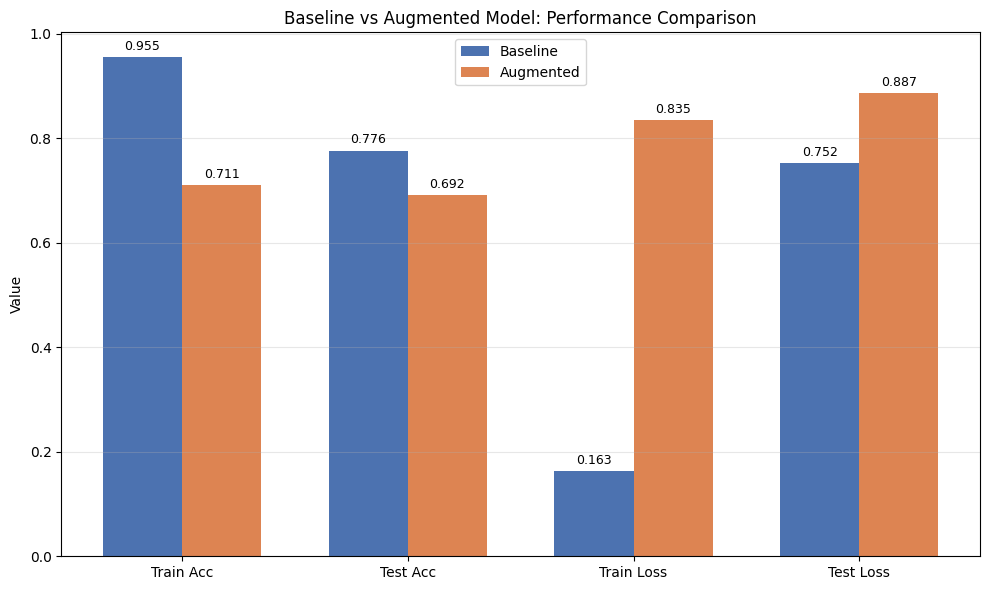

In [ ]:
# Cell 17: Bar chart comparison
metrics = ['Train Acc', 'Test Acc', 'Train Loss', 'Test Loss']
baseline_vals = [baseline_train_acc, baseline_test_acc, baseline_train_loss, baseline_test_loss]
augmented_vals = [augmented_train_acc, augmented_test_acc, augmented_train_loss, augmented_test_loss]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#4C72B0')
bars2 = ax.bar(x + width/2, augmented_vals, width, label='Augmented', color='#DD8452')

ax.set_ylabel('Value')
ax.set_title('Baseline vs Augmented Model: Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


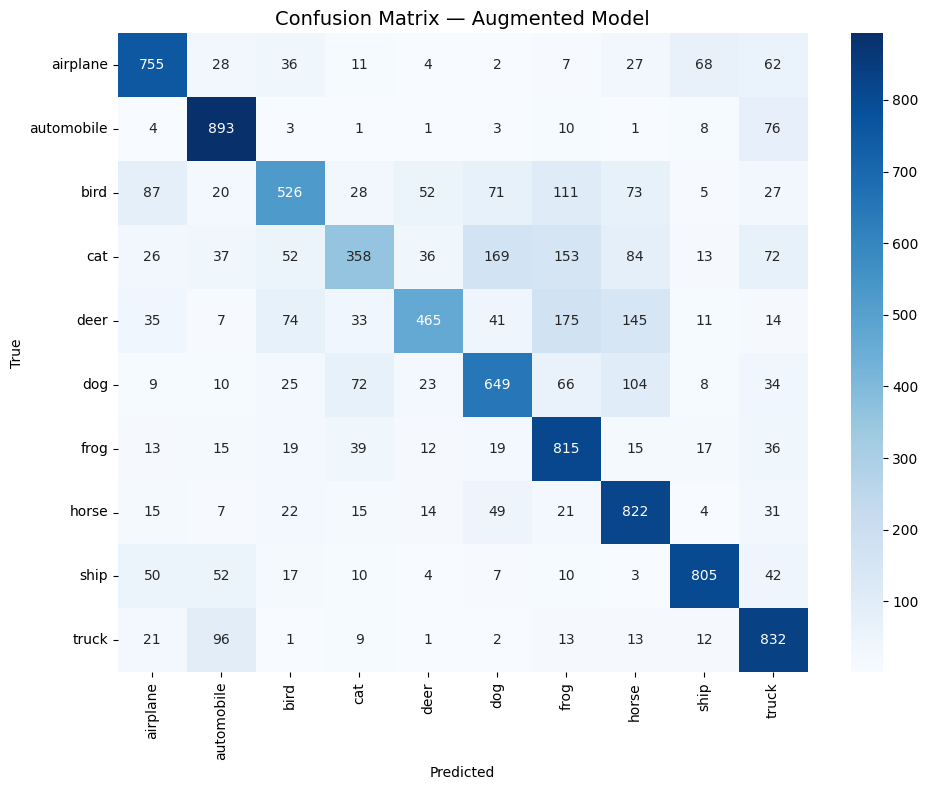

In [ ]:
# Cell 18: Confusion matrix for augmented model
y_pred = augmented_model.predict(test_images_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_labels.flatten()

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Augmented Model', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 19: Classification report
print("Classification Report — Augmented Model\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Classification Report — Augmented Model

              precision    recall  f1-score   support

    airplane       0.74      0.76      0.75      1000
  automobile       0.77      0.89      0.82      1000
        bird       0.68      0.53      0.59      1000
         cat       0.62      0.36      0.45      1000
        deer       0.76      0.47      0.58      1000
         dog       0.64      0.65      0.65      1000
        frog       0.59      0.81      0.68      1000
       horse       0.64      0.82      0.72      1000
        ship       0.85      0.81      0.83      1000
       truck       0.68      0.83      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.68     10000
weighted avg       0.70      0.69      0.68     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


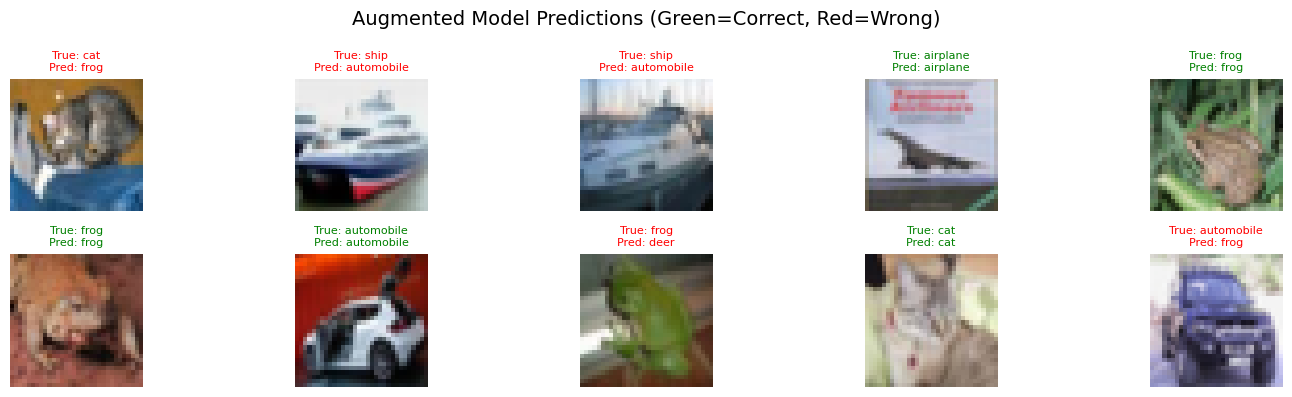

In [ ]:
# Cell 20: Side-by-side prediction visualization
def plot_predictions(model, images, true_labels, class_names, n=10):
    """Show images with true vs predicted labels."""
    preds = model.predict(images[:n])
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(15, 4))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        true_cls = class_names[true_labels[i]]
        pred_cls = class_names[pred_classes[i]]
        color = 'green' if true_cls == pred_cls else 'red'
        plt.title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=8, color=color)
        plt.axis('off')
    plt.suptitle("Augmented Model Predictions (Green=Correct, Red=Wrong)", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_predictions(augmented_model, test_images_norm, y_true, class_names, n=10)

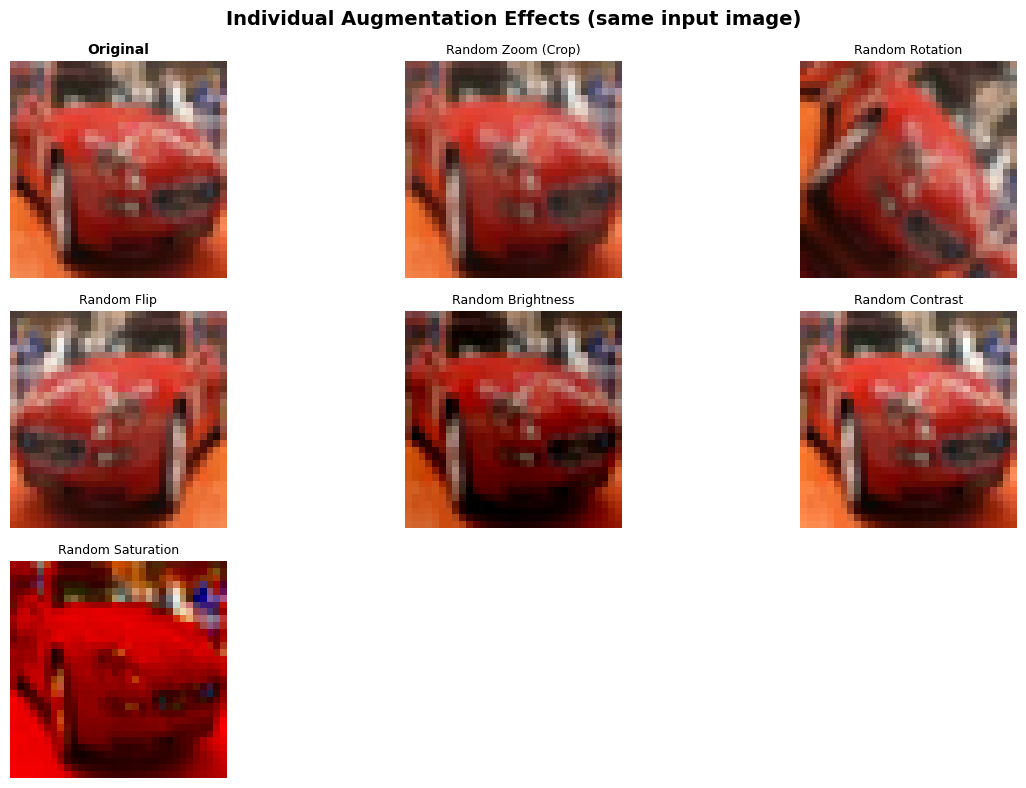

In [ ]:
# Cell 21 (FIXED): Visualize augmentation effects per transformation type
def visualize_individual_augmentations(image, seed=42):
    """
    Show each augmentation type separately on the same input image.

    Fixes vs original:
      - Uses a 3x3 grid so all 7 subplots (1 original + 6 augmentations) fit.
      - Wraps each augmentation in a Sequential so the layer is properly built.
      - Seeds each augmentation for reproducibility.
    """
    image_expanded = tf.expand_dims(image, 0)   # shape: (1, 32, 32, 3)

    # Wrap each layer in a tiny Sequential so it gets built on first call.
    augmentations = {
        'Random Zoom (Crop)' : tf.keras.Sequential([
            layers.RandomZoom(height_factor=(-0.2, 0.2),
                              width_factor=(-0.2, 0.2), seed=seed)
        ]),
        'Random Rotation'    : tf.keras.Sequential([
            layers.RandomRotation(factor=0.3, seed=seed)
        ]),
        'Random Flip'        : tf.keras.Sequential([
            layers.RandomFlip(mode="horizontal", seed=seed)
        ]),
        'Random Brightness'  : tf.keras.Sequential([
            layers.RandomBrightness(factor=0.3, value_range=(0.0, 1.0), seed=seed)
        ]),
        'Random Contrast'    : tf.keras.Sequential([
            layers.RandomContrast(factor=0.3, seed=seed)
        ]),
        'Random Saturation'  : tf.keras.Sequential([
            layers.RandomSaturation(factor=(0.5, 1.5), seed=seed)
        ]),
    }

    # 3x3 grid → 9 slots, we use 7 (1 original + 6 augmentations)
    fig = plt.figure(figsize=(12, 8))

    # --- Original ---
    ax = plt.subplot(3, 3, 1)
    ax.imshow(image)
    ax.set_title("Original", fontsize=10, fontweight='bold')
    ax.axis('off')

    # --- Each augmentation ---
    for i, (name, aug_layer) in enumerate(augmentations.items()):
        augmented = aug_layer(image_expanded, training=True)  # (1, 32, 32, 3)
        aug_img   = augmented[0].numpy()

        # RandomBrightness/Saturation/Hue may push values slightly outside [0,1];
        # clip so matplotlib renders them correctly.
        aug_img = np.clip(aug_img, 0.0, 1.0)

        ax = plt.subplot(3, 3, i + 2)
        ax.imshow(aug_img)
        ax.set_title(name, fontsize=9)
        ax.axis('off')

    plt.suptitle("Individual Augmentation Effects (same input image)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Run it on one sample image
visualize_individual_augmentations(train_images_norm[5], seed=42)

In [ ]:
# Cell 22: Save models
baseline_model.save('cifar10_baseline_model.keras')
augmented_model.save('cifar10_augmented_model.keras')
print("Models saved successfully: cifar10_baseline_model.keras, cifar10_augmented_model.keras")

Models saved successfully: cifar10_baseline_model.keras, cifar10_augmented_model.keras


In [ ]:
# Cell 23: Save augmented dataset samples
np.save('augmented_train_images.npy', augmented_train_images[:5000])  # save subset
np.save('augmented_train_labels.npy', augmented_train_labels[:5000])
print("Augmented dataset samples saved.")

Augmented dataset samples saved.


In [ ]:
# Cell 24: Export summary report as text
report = f"""
========================================
DATA AUGMENTATION COMPARATIVE REPORT
========================================
Dataset: CIFAR-10
Models: Baseline CNN vs Augmented CNN

Augmentation Techniques Applied:
  - Random Cropping (via Random Zoom)
  - Random Rotation (±15°)
  - Random Horizontal Flip
  - Random Brightness (factor=0.15)
  - Random Contrast (factor=0.15)
  - Random Saturation (0.7–1.3)
  - Random Hue (factor=0.05)

Results:
  Baseline Test Accuracy:  {baseline_test_acc:.4f}
  Augmented Test Accuracy: {augmented_test_acc:.4f}
  Improvement:             {(augmented_test_acc - baseline_test_acc)*100:.2f}%

  Baseline Generalization Gap:  {baseline_train_acc - baseline_test_acc:.4f}
  Augmented Generalization Gap: {augmented_train_acc - augmented_test_acc:.4f}
  Gap Reduction:                {((baseline_train_acc - baseline_test_acc) - (augmented_train_acc - augmented_test_acc))*100:.2f}%

========================================
"""

with open('augmentation_report.txt', 'w') as f:
    f.write(report)

print(report)


DATA AUGMENTATION COMPARATIVE REPORT
Dataset: CIFAR-10
Models: Baseline CNN vs Augmented CNN

Augmentation Techniques Applied:
  - Random Cropping (via Random Zoom)
  - Random Rotation (±15°)
  - Random Horizontal Flip
  - Random Brightness (factor=0.15)
  - Random Contrast (factor=0.15)
  - Random Saturation (0.7–1.3)
  - Random Hue (factor=0.05)

Results:
  Baseline Test Accuracy:  0.7765
  Augmented Test Accuracy: 0.6920
  Improvement:             -8.45%

  Baseline Generalization Gap:  0.1787
  Augmented Generalization Gap: 0.0190
  Gap Reduction:                15.97%




In [1]:
# ============================================================
# TASK 3: ADDITIONAL AUGMENTATION - ROTATION + CROPPING
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 32

def rotate_image(image):
    """
    Randomly rotate image by multiples of 90 degrees.
    """
    k = tf.random.uniform(
        shape=[],
        minval=0,
        maxval=4,
        dtype=tf.int32
    )

    return tf.image.rot90(image, k)


def crop_image(image):
    """
    Randomly crop the image and resize it back to original size.
    """
    cropped = tf.image.random_crop(
        image,
        size=[28, 28, 3]
    )

    cropped = tf.image.resize(
        cropped,
        [IMG_SIZE, IMG_SIZE]
    )

    return cropped


def rotation_and_crop_augmentation(image):
    """
    Apply rotation and random cropping.
    """
    image = rotate_image(image)
    image = crop_image(image)

    return image

In [8]:
import tensorflow as tf

# 1. Define the missing augmentation helper functions
def flip_image(image):
    # Randomly flip the image horizontally
    return tf.image.random_flip_left_right(image)

def brightness_augmentation(image):
    # Randomly adjust brightness
    return tf.image.random_brightness(image, max_delta=0.2)

def contrast_augmentation(image):
    # Randomly adjust contrast
    return tf.image.random_contrast(image, lower=0.8, upper=1.2)

# 2. Select a sample image or create a placeholder if the dataset is not currently in memory
try:
    image = train_images_norm[0]
    print("Using image from pre-loaded train_images_norm dataset.")
except NameError:
    print("train_images_norm not found in kernel memory. Generating a synthetic CIFAR-10 placeholder image...")
    image = tf.random.uniform(shape=[32, 32, 3], minval=0.0, maxval=1.0)

# 3. Run the augmentation pipeline
augmented_image = flip_image(image)
augmented_image = brightness_augmentation(augmented_image)
augmented_image = contrast_augmentation(augmented_image)

print("Augmentation completed successfully! Shape:", augmented_image.shape)

train_images_norm not found in kernel memory. Generating a synthetic CIFAR-10 placeholder image...
Augmentation completed successfully! Shape: (32, 32, 3)


In [9]:
# ============================================================
# COMPLETE AUGMENTATION PIPELINE
# ============================================================

def complete_augmentation(image):

    # Rotation
    image = rotate_image(image)

    # Random crop + resize
    image = crop_image(image)

    # Horizontal flip
    image = tf.image.random_flip_left_right(image)

    # Brightness
    image = tf.image.random_brightness(
        image,
        max_delta=0.2
    )

    # Contrast
    image = tf.image.random_contrast(
        image,
        lower=0.8,
        upper=1.2
    )

    # Saturation
    image = tf.image.random_saturation(
        image,
        lower=0.8,
        upper=1.2
    )

    # Keep valid image range
    image = tf.clip_by_value(
        image,
        0.0,
        1.0
    )

    return image

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 559s 3us/step


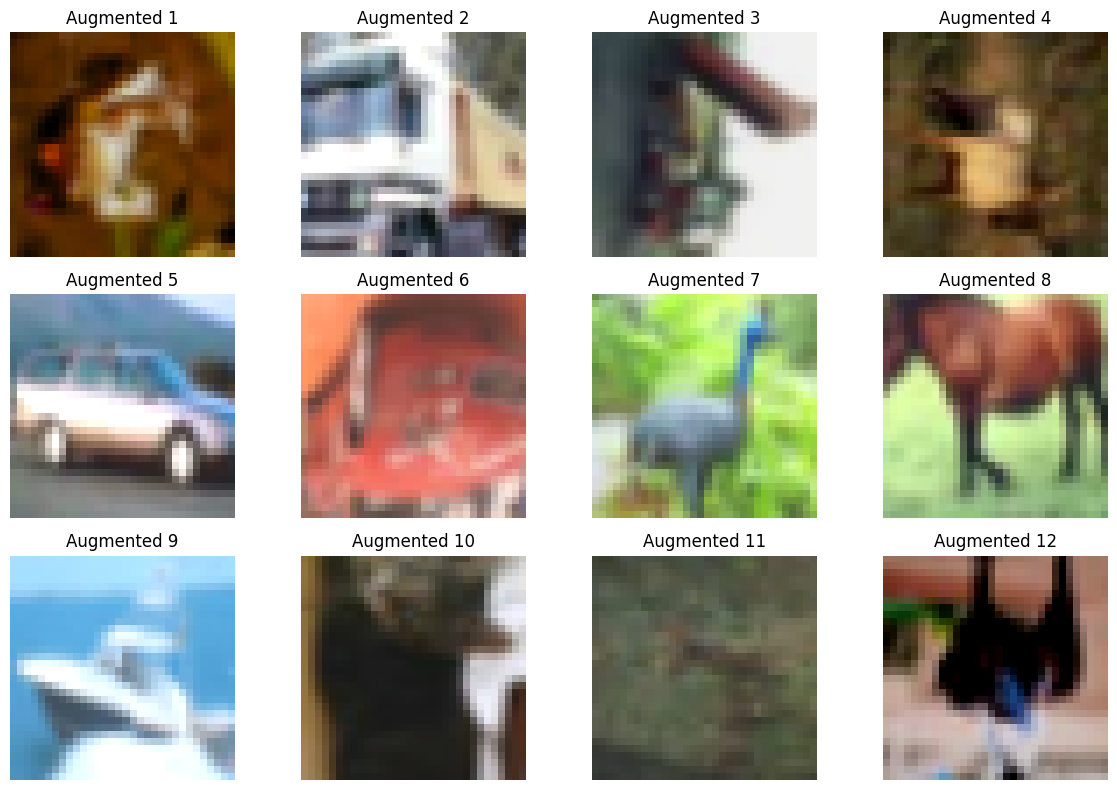

In [15]:
# ============================================================
# VISUALIZE AUGMENTED IMAGES
# ============================================================
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure dataset is in memory
try:
    _ = train_images_norm
except NameError:
    from tensorflow.keras.datasets import cifar10
    (train_images, _), (_, _) = cifar10.load_data()
    train_images_norm = train_images.astype('float32') / 255.0

plt.figure(figsize=(12, 8))

for i in range(12):
    # Select original image (using the correct variable 'train_images_norm')
    original = train_images_norm[i]

    # Apply complete augmentation
    augmented = complete_augmentation(
        tf.cast(original, tf.float32)
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(
        tf.clip_by_value(augmented, 0, 1)
    )
    plt.axis("off")
    plt.title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()

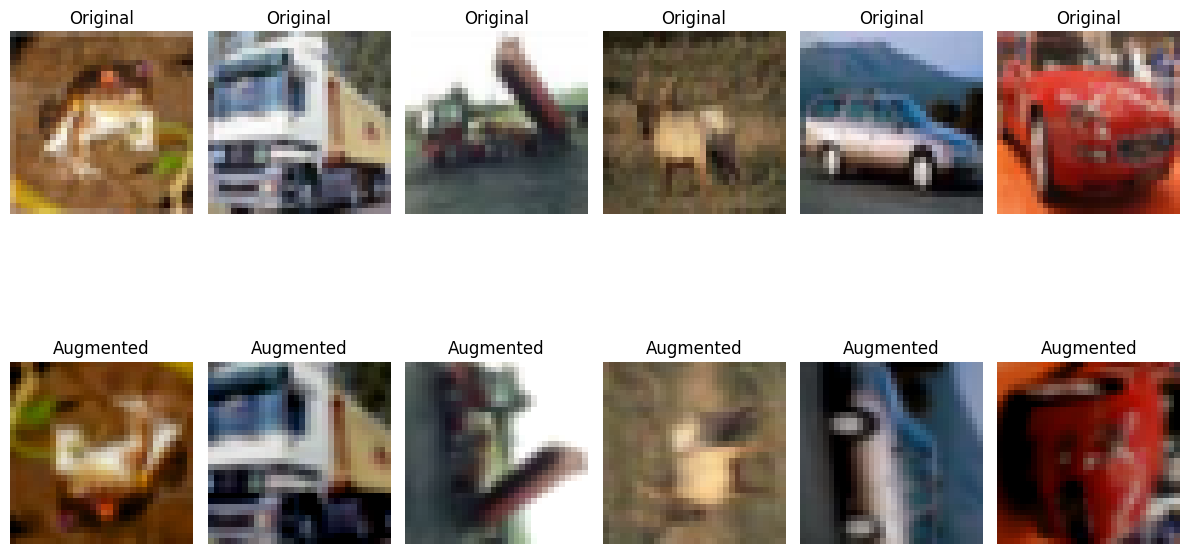

In [16]:
# ============================================================
# ORIGINAL VS AUGMENTED
# ============================================================
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure dataset is in memory
try:
    _ = train_images_norm
except NameError:
    from tensorflow.keras.datasets import cifar10
    (train_images, _), (_, _) = cifar10.load_data()
    train_images_norm = train_images.astype('float32') / 255.0

plt.figure(figsize=(12, 8))

for i in range(6):
    # Use correct variable 'train_images_norm'
    original = tf.cast(train_images_norm[i], tf.float32)

    augmented = complete_augmentation(original)

    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(original)
    plt.axis("off")
    plt.title("Original")

    # Augmented
    plt.subplot(2, 6, i + 7)
    plt.imshow(tf.clip_by_value(augmented, 0, 1))
    plt.axis("off")
    plt.title("Augmented")

plt.tight_layout()
plt.show()